<a href="https://colab.research.google.com/github/Navjotkhatri/DeepFER-Facial-Emotion-Recognition-Using-Deep-Learning/blob/main/DeepFER_Facial_Emotion_Recognition_Using_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -  DeepFER: Facial Emotion Recognition Using Deep Learning



##### **Project Type**    - DeepFER: Facial Emotion Recognition Using Deep Learning
##### **Contribution**    - Individual

# **Project Summary -**

The primary goal of DeepFER: Facial Emotion Recognition Using Deep Learning is to develop an advanced and efficient system capable of accurately identifying and classifying human emotions from facial expressions in real-time. By leveraging state-of-the-art Convolutional Neural Networks (CNNs) and Transfer Learning techniques, this project aims to create a robust model that can handle the inherent variability in facial expressions and diverse image conditions. The system will be trained on a comprehensive dataset featuring seven distinct emotions: angry, sad, happy, fear, neutral, disgust, and surprise. The ultimate objective is to achieve high accuracy and reliability, making DeepFER suitable for applications in human-computer interaction, mental health monitoring, customer service, and beyond. Through this project, we aim to bridge the gap between cutting-edge AI research and practical emotion recognition applications, contributing to more empathetic and responsive machine interactions with humans.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


DeepFER: Facial Emotion Recognition Using Deep Learning aims to develop a robust and efficient system for recognizing emotions from facial expressions using advanced deep learning techniques. This project leverages Convolutional Neural Networks (CNNs) and Transfer Learning to accurately classify emotions such as happiness, sadness, anger, surprise, and more from images of human faces. The system will be trained on a diverse dataset of facial images, employing data augmentation and fine-tuning methods to enhance its performance. By integrating state-of-the-art computer vision algorithms and neural network architectures, DeepFER seeks to achieve high accuracy and real-time processing capabilities. The ultimate goal is to create a versatile tool that can be applied in various fields, including human-computer interaction, mental health monitoring, and customer service, enhancing the way machines understand and respond to human emotions.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

# **Data Collection and Preprocessing:**

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries

import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [3]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    GlobalAveragePooling2D,
    Input
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.models import load_model

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications import VGG16

In [5]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.utils import plot_model

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [6]:
# Load Dataset

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
zip_path='/content/drive/MyDrive/ML Engineer/proj 5 Facial Emotion Recognition/Face Emotion Recognition Dataset.zip'

In [9]:
# import zipfile
# import os

# extract_path = "/content/drive/MyDrive/ML Engineer"

# os.makedirs(extract_path, exist_ok=True)
# #
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("Dataset extracted successfully!")

### Dataset First View

In [10]:
import shutil
import os

source = "/content/drive/MyDrive/ML Engineer/proj 5 Facial Emotion Recognition/images"
destination = "/content/images"

if not os.path.exists(destination):
    shutil.copytree(source, destination)

print("Dataset copied successfully!")

Dataset copied successfully!


In [11]:
train_dir = "/content/images/train"
validation_dir = "/content/images/validation"

In [12]:
# train_dir='/content/drive/MyDrive/ML Engineer/proj 5 Facial Emotion Recognition/images/train'
# validation_dir='/content/drive/MyDrive/ML Engineer/proj 5 Facial Emotion Recognition/images/validation'

In [13]:
emotion_classes = sorted(os.listdir(train_dir))

print("Emotion Classes:")
print(emotion_classes)

print("\nTotal Emotion Categories:", len(emotion_classes))

Emotion Classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Total Emotion Categories: 7


In [14]:
print("Training Dataset Distribution\n")

total_images = 0

for emotion in emotion_classes:
    count = len(os.listdir(os.path.join(train_dir, emotion)))
    total_images += count
    print(f"{emotion:<12}: {count}")

print("\nTotal Training Images:", total_images)

Training Dataset Distribution

angry       : 3993
disgust     : 436
fear        : 4103
happy       : 7164
neutral     : 4982
sad         : 4938
surprise    : 3205

Total Training Images: 28821


In [15]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    fill_mode='nearest'
)

In [16]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [17]:
IMAGE_SIZE = (128,128)
BATCH_SIZE = 32

In [18]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

Found 28821 images belonging to 7 classes.


In [19]:
validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 7066 images belonging to 7 classes.


In [20]:
print(train_generator.class_indices)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


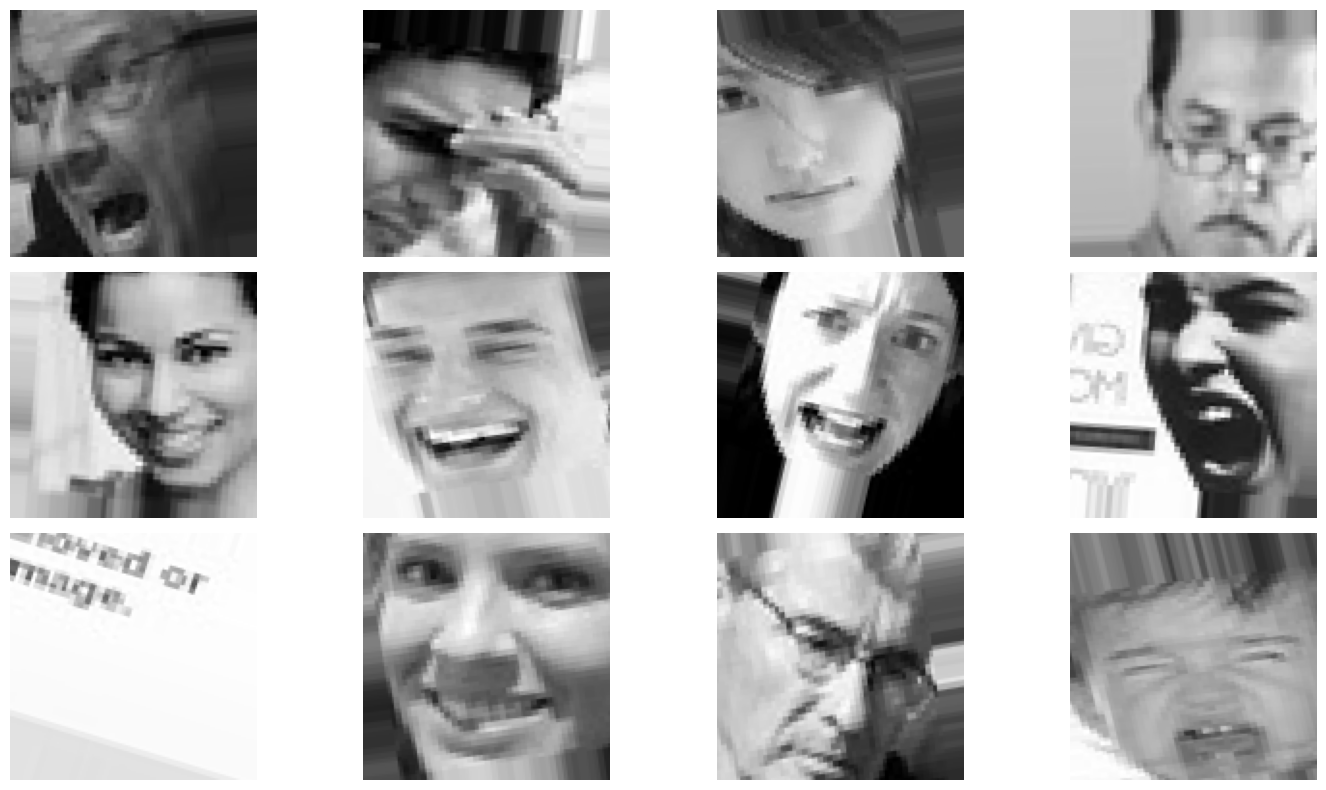

In [21]:
images, labels = next(train_generator)

plt.figure(figsize=(15,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Before model training, all images are resized to 224 × 224 pixels to ensure uniform input dimensions compatible with the selected deep learning architecture. Pixel values are normalized to the range [0, 1] by dividing each pixel by 255, which accelerates model convergence and stabilizes training.

To improve the model's ability to generalize, several data augmentation techniques are applied exclusively to the training dataset. These include random rotations, horizontal flipping, width and height shifts, shearing, and zooming. Data augmentation increases the diversity of training samples without collecting additional data, thereby reducing overfitting and improving performance on unseen images.

In [22]:
print(train_generator.image_shape)

(128, 128, 3)


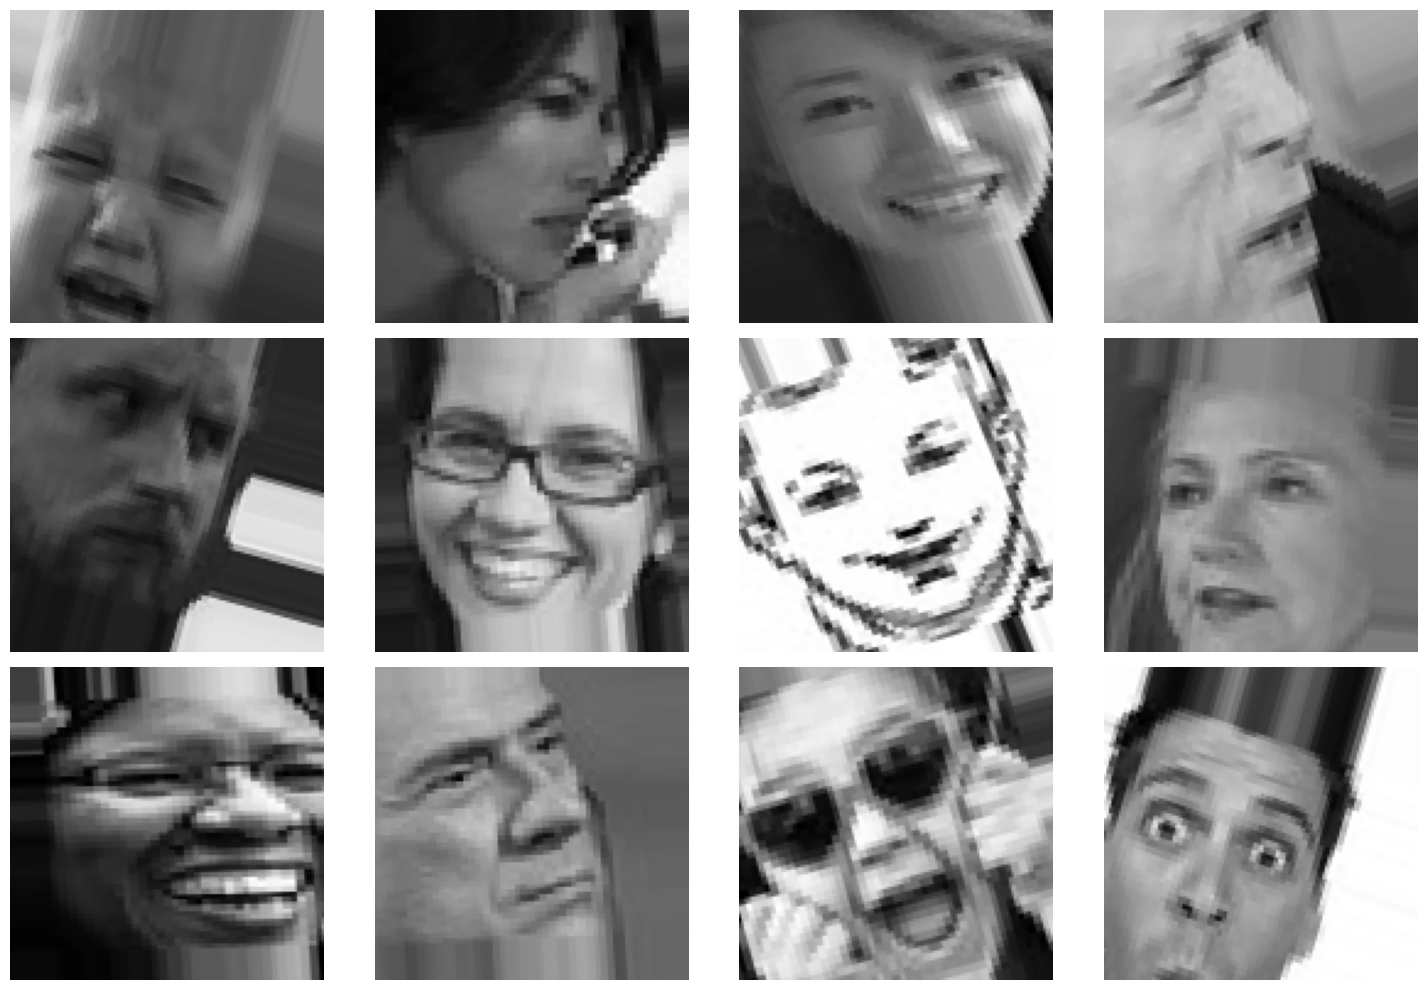

In [23]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(15,10))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Model Development:**


## CNN Model

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(7, activation='softmax')

])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,783,687 (10.62 MB)

 Trainable params: 2,782,727 (10.62 MB)

 Non-trainable params: 960 (3.75 KB)

In [25]:
from tensorflow.keras.optimizers import Adam

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [26]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.1967 - loss: 2.1215
Epoch 1: val_accuracy improved from None to 0.27639, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 176s 181ms/step - accuracy: 0.2106 - loss: 1.9502 - val_accuracy: 0.2764 - val_loss: 1.7857 - learning_rate: 1.0000e-04
Epoch 2/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.2335 - loss: 1.8537
Epoch 2: val_accuracy improved from 0.27639 to 0.29394, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 154s 170ms/step - accuracy: 0.2384 - loss: 1.8447 - val_accuracy: 0.2939 - val_loss: 1.7358 - learning_rate: 1.0000e-04
Epoch 3/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.2464 - loss: 1.8269
Epoch 3: val_accuracy did not improve from 0.29394
901/901 ━━━━━━━━━━━━━━━━━━━━ 152s 168ms/step - accuracy: 0.2498 - loss: 1.8164 - val_accurac

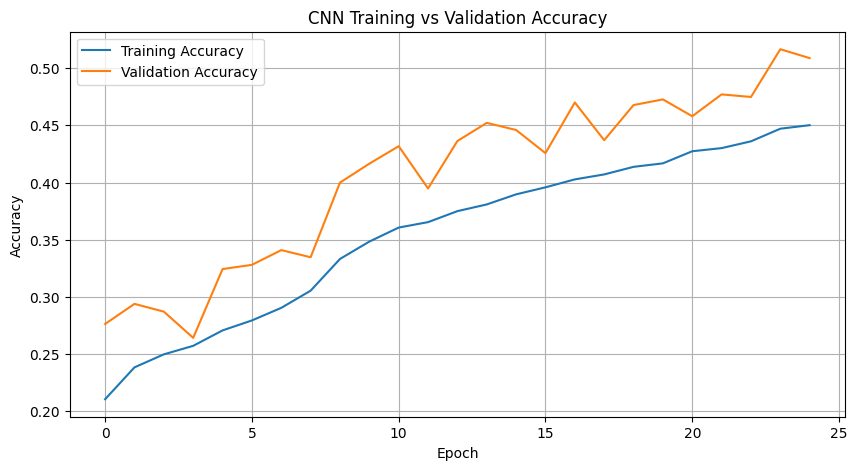

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

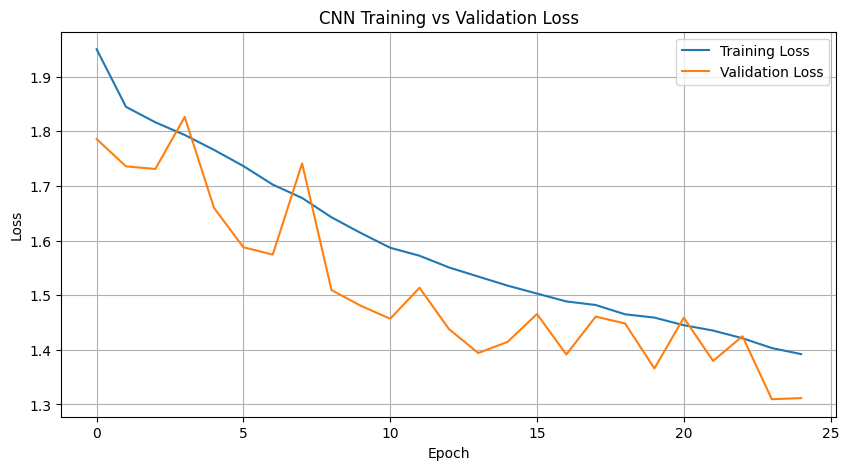

In [28]:
plt.figure(figsize=(10,5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
loss, accuracy = cnn_model.evaluate(validation_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5166 - loss: 1.3095
Validation Loss: 1.3095
Validation Accuracy: 0.5166


In [30]:
import numpy as np

predictions = cnn_model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step


In [31]:
from sklearn.metrics import classification_report

class_names = list(validation_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

       angry       0.38      0.01      0.02       960
     disgust       0.00      0.00      0.00       111
        fear       0.33      0.16      0.22      1018
       happy       0.78      0.86      0.82      1825
     neutral       0.47      0.54      0.50      1216
         sad       0.30      0.61      0.40      1139
    surprise       0.71      0.69      0.70       797

    accuracy                           0.52      7066
   macro avg       0.42      0.41      0.38      7066
weighted avg       0.51      0.52      0.48      7066



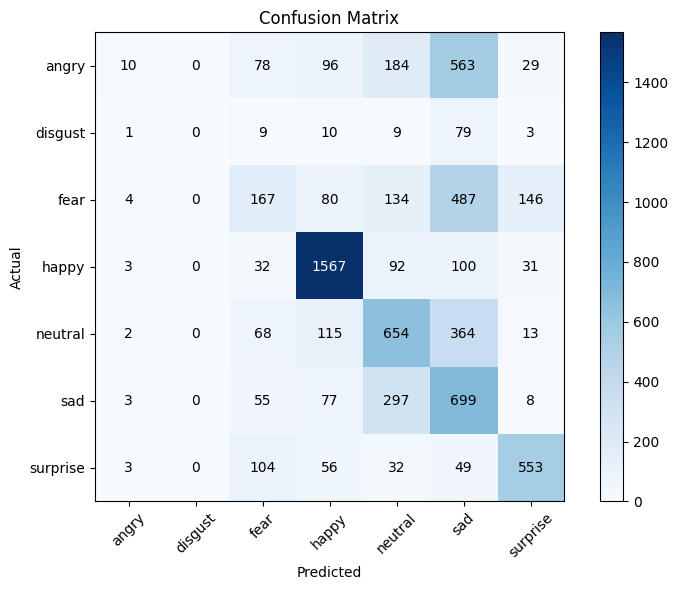

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [33]:
cnn_model.save("DeepFER_CNN_Model.keras")

In [1]:
import os

for emotion in sorted(os.listdir(train_dir)):
    print(f"{emotion}: {len(os.listdir(os.path.join(train_dir, emotion)))}")

NameError: name 'train_dir' is not defined

In [50]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.031125898894494), 1: np.float64(9.443315858453474), 2: np.float64(1.0034817729187702), 3: np.float64(0.5747188322565207), 4: np.float64(0.8264322991340254), 5: np.float64(0.8337962159347335), 6: np.float64(1.2846445286382884)}


In [51]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)

Epoch 1/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.4531 - loss: 1.7366
Epoch 1: val_accuracy did not improve from 0.51868
901/901 ━━━━━━━━━━━━━━━━━━━━ 175s 186ms/step - accuracy: 0.4538 - loss: 1.7315 - val_accuracy: 0.5122 - val_loss: 1.3218 - learning_rate: 4.0000e-06
Epoch 2/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.4544 - loss: 1.7032
Epoch 2: val_accuracy did not improve from 0.51868
901/901 ━━━━━━━━━━━━━━━━━━━━ 156s 173ms/step - accuracy: 0.4532 - loss: 1.7307 - val_accuracy: 0.5142 - val_loss: 1.3228 - learning_rate: 4.0000e-06
Epoch 3/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.4554 - loss: 1.7089
Epoch 3: val_accuracy did not improve from 0.51868
901/901 ━━━━━━━━━━━━━━━━━━━━ 149s 165ms/step - accuracy: 0.4576 - loss: 1.6994 - val_accuracy: 0.5144 - val_loss: 1.3161 - learning_rate: 4.0000e-06
Epoch 4/25
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.4592 - loss: 1.6693
Epoch 4: val_accuracy did not improve from 0.518

In [52]:
loss, accuracy = cnn_model.evaluate(validation_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5122 - loss: 1.3218
Validation Loss: 1.3218
Validation Accuracy: 0.5122


In [53]:
from sklearn.metrics import classification_report

class_names = list(validation_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

       angry       0.38      0.01      0.02       960
     disgust       0.00      0.00      0.00       111
        fear       0.33      0.16      0.22      1018
       happy       0.78      0.86      0.82      1825
     neutral       0.47      0.54      0.50      1216
         sad       0.30      0.61      0.40      1139
    surprise       0.71      0.69      0.70       797

    accuracy                           0.52      7066
   macro avg       0.42      0.41      0.38      7066
weighted avg       0.51      0.52      0.48      7066



During initial experimentation, the CNN model struggled to classify minority emotion classes, particularly Disgust, due to severe class imbalance. To mitigate this issue, class weights were applied during training, assigning greater importance to underrepresented classes. This encouraged the model to learn more balanced decision boundaries across all seven emotion categories and improved recognition of minority emotions.

## **MobileNetV2**

In [37]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [38]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [39]:
validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

In [40]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


In [41]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.031125898894494), 1: np.float64(9.443315858453474), 2: np.float64(1.0034817729187702), 3: np.float64(0.5747188322565207), 4: np.float64(0.8264322991340254), 5: np.float64(0.8337962159347335), 6: np.float64(1.2846445286382884)}


In [42]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [43]:
base_model.trainable = False

In [44]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(7, activation='softmax')(x)

transfer_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [45]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
transfer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,052,103 (11.64 MB)

 Trainable params: 791,559 (3.02 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [47]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)

Epoch 1/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.1947 - loss: 2.3388
Epoch 1: val_accuracy improved from None to 0.30484, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 485s 512ms/step - accuracy: 0.2178 - loss: 2.1338 - val_accuracy: 0.3048 - val_loss: 1.7476 - learning_rate: 1.0000e-04
Epoch 2/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.2592 - loss: 1.8642
Epoch 2: val_accuracy improved from 0.30484 to 0.32041, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 424s 471ms/step - accuracy: 0.2660 - loss: 1.8508 - val_accuracy: 0.3204 - val_loss: 1.7217 - learning_rate: 1.0000e-04
Epoch 3/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.2814 - loss: 1.7869
Epoch 3: val_accuracy improved from 0.32041 to 0.34192, saving model to best_cnn_model.keras

Epoch 3: finished saving model to best_cnn_model.

In [48]:
base_model.trainable = True

In [49]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [50]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [1]:
history_finetune = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)

NameError: name 'transfer_model' is not defined

In [ ]:
loss, accuracy = transfer_model.evaluate(validation_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

In [ ]:
import numpy as np

predictions = transfer_model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

In [ ]:
from sklearn.metrics import classification_report

class_names = list(validation_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Transfer Learning

In [34]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout

In [35]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [36]:
base_model.trainable = False

In [37]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(7, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

In [38]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Fine-Tuning

In [40]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [41]:
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

A custom Convolutional Neural Network (CNN) was designed to classify facial expressions into seven emotion categories. The network consists of multiple convolutional layers for feature extraction, batch normalization for training stability, max-pooling layers for dimensionality reduction, dropout layers to reduce overfitting, and fully connected layers for final classification.

In addition to the custom CNN, Transfer Learning was implemented using the pre-trained MobileNetV2 architecture. The convolutional base, pre-trained on the ImageNet dataset, was used as a feature extractor by replacing its original classification layer with a new classifier tailored to the seven emotion classes. Initially, the pre-trained layers were frozen, allowing only the new classification layers to learn. In the fine-tuning stage, the final layers of MobileNetV2 were unfrozen and trained with a reduced learning rate to adapt the learned features specifically to facial emotion recognition while retaining the robust representations learned from ImageNet.

In [42]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_deepfer_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [43]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [44]:
print(train_generator.samples)

28821


In [45]:
print(train_generator.image_shape)

(128, 128, 3)


In [46]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [47]:
print(train_generator.batch_size)

32


Training cnn

In [48]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.4525 - loss: 1.3890
Epoch 1: val_accuracy improved from None to 0.51429, saving model to best_deepfer_model.keras

Epoch 1: finished saving model to best_deepfer_model.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 151s 167ms/step - accuracy: 0.4497 - loss: 1.3925 - val_accuracy: 0.5143 - val_loss: 1.3059 - learning_rate: 2.0000e-05
Epoch 2/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.4525 - loss: 1.3922
Epoch 2: val_accuracy did not improve from 0.51429
901/901 ━━━━━━━━━━━━━━━━━━━━ 147s 163ms/step - accuracy: 0.4531 - loss: 1.3888 - val_accuracy: 0.5086 - val_loss: 1.3244 - learning_rate: 2.0000e-05
Epoch 3/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.4499 - loss: 1.3874
Epoch 3: val_accuracy improved from 0.51429 to 0.51684, saving model to best_deepfer_model.keras

Epoch 3: finished saving model to best_deepfer_model.keras
901/901 ━━━━━━━━━━━━━━━━━━━━ 145s 160ms/step - accuracy: 0.4518 - loss: 1.38

KeyboardInterrupt: 

training mobilenetv2

In [ ]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

In [ ]:
history_finetune = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
loss, accuracy = transfer_model.evaluate(validation_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

In [ ]:
import numpy as np

predictions = transfer_model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

In [ ]:
from sklearn.metrics import classification_report

class_names = list(validation_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The DeepFER models were trained using the augmented training dataset and evaluated on an independent validation dataset. To improve training efficiency and prevent overfitting, Early Stopping, ReduceLROnPlateau, and Model Checkpoint callbacks were incorporated. The custom CNN and MobileNetV2 Transfer Learning models were both trained using categorical cross-entropy loss and the Adam optimizer. Model performance was assessed using validation accuracy, precision, recall, F1-score, and confusion matrix analysis. Training and validation accuracy/loss curves were also analyzed to evaluate convergence and detect any signs of overfitting.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***